# About Dataset

Scenario
A fast-food chain plans to add a new item to its menu. However, they are still undecided between three possible marketing campaigns for promoting the new product. In order to determine which promotion has the greatest effect on sales, the new item is introduced at locations in several randomly selected markets. A different promotion is used at each location, and the weekly sales of the new item are recorded for the first four weeks.

**Goal**
                                                                                                                <span style="background-color:yellow;">Evaluate A/B testing results and decide which marketing strategy works the best.</span>
                                                                                                                                                                                                                                                                                          


**Columns**

<span style="color:blue;">MarketID</span> : unique identifier for market

<span style="color:blue;">MarketSize</span>  : size of market area by sales

<span style="color:blue;">LocationID</span>  : unique identifier for store location

<span style="color:blue;">AgeOfStore</span>  : age of store in years


<span style="color:blue;">Promotion</span> : one of three promotions that were tested

<span style="color:blue;">week</span> : one of four weeks when the promotions were run

<span style="color:blue;">SalesInThousands</span> : sales amount for a specific LocationID, Promotion, and week



# About methodology 

A/B Testing (also known as split testing or bucket testing) is a controlled experiment in which two or more variants (A and B) of a webpage, app, marketing campaign, or other product are compared to determine which one performs better based on a predefined metric or goal. It is a fundamental method used in data-driven decision-making to optimize user experience, conversions, engagement, or other key performance indicators (KPIs).


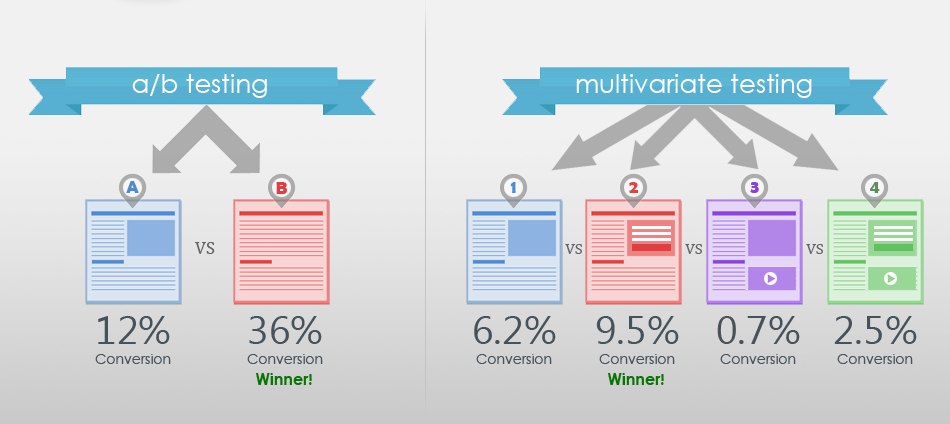


**In our case it is a multivariate testing case, we test the 3 promotion plans to know whether there is an effect for choosing a specific plan on sales or not.**



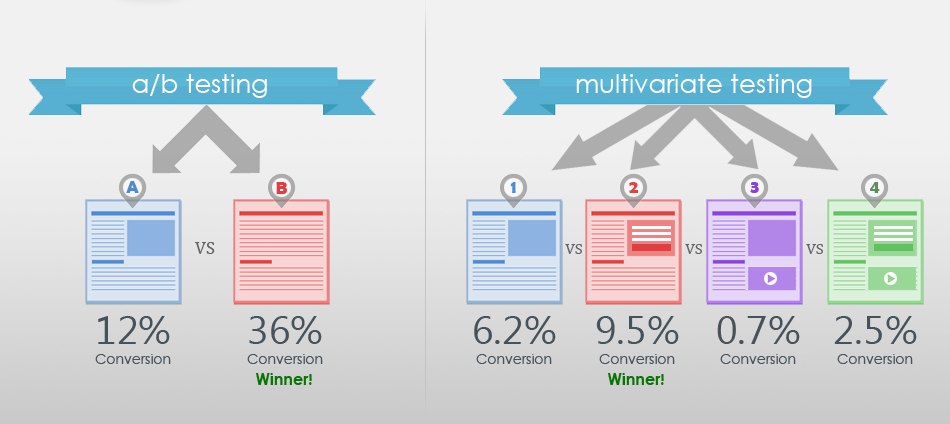



<div style="border-radius:10px; border:#632626 solid; padding: 15px; background-color:#CBC3E3 ; font-size:100%; text-align:left">

<h3 align="center"><font color='#11324D'> In this notebook , we will go forward as following :  </font></h3>
  
* [Data Preprocessing and feature engineering ](#Data-processing-and-feature-engineering)

* [Exploratory data analysis (EDA)](#Exploratory-data-analysis)

* [Validating tests'  assumptions ](#Validating-tests'-assumptions )

* [Running the test ](#run-the-test)

* [Studying confounding variables effect ](#Studying-confounding-variables-effect )



### Data processing and feature engineering


<div style="border-radius: 20px; border:#9B8BA8 solid; padding: 15px; background-color: #A6E6FA; font-size:130%; text-align:center">

# A - Data Preprocessing and feature engineering 


First , we import libraries and dataset

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats  
import warnings

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fast-food-marketing-campaign-ab-test/WA_Marketing-Campaign.csv


In [2]:
warnings.filterwarnings("ignore", category=DeprecationWarning) 

In [3]:
df = pd.read_csv("/kaggle/input/fast-food-marketing-campaign-ab-test/WA_Marketing-Campaign.csv")

then we explore data types , missing values presence

In [4]:
df.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB


We have these variables 'MarketID' , 'LocationID' , 'Promotion' , and 'week' they refer to categories , however they are encoded as integers , so we encode them to be of "category" type to avoid dealing with them as numeric data 

In [6]:
df['MarketID'] = df['MarketID'].astype('category')
df['LocationID'] = df['LocationID'].astype('category')
df['Promotion'] = df['Promotion'] .astype('category')
df['week'] = df['week'] .astype('category')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   MarketID          548 non-null    category
 1   MarketSize        548 non-null    object  
 2   LocationID        548 non-null    category
 3   AgeOfStore        548 non-null    int64   
 4   Promotion         548 non-null    category
 5   week              548 non-null    category
 6   SalesInThousands  548 non-null    float64 
dtypes: category(4), float64(1), int64(1), object(1)
memory usage: 21.5+ KB


We see from the above stats that Age of store is a discrete variable , it may be a good idea to deal with it as an ordinal variable.

Thus to study its interaction with "SalesInThousands" better idea would be to divide it into low , medium, and old age categories. better than scatter plot , or correlation for example

In [8]:
df[ "store_age"]=pd.qcut(df['AgeOfStore'] , q=3 , labels = ['new' , 'middle' , 'old'])

In [9]:
df.isna().sum()

MarketID            0
MarketSize          0
LocationID          0
AgeOfStore          0
Promotion           0
week                0
SalesInThousands    0
store_age           0
dtype: int64

<div style="border-radius: 22px; font-size:130%; text-align:left">


good enough data contain no missing variables 

### Exploratory data analysis


<div style="border-radius: 20px; border:#9B8BA8 solid; padding: 15px; background-color: #A6E6FA; font-size:130%; text-align:center">

# B - Exploratory data analysis (EDA)



<div style="border-radius: 22px; font-size:200%; text-align:center">


Actually there are multiple components inside the process of Exploratory data analysis. Here , and generally in each task we focus on statistics , plots that help us in our objective.


<div style="border-radius: 22px; font-size:150%; text-align:left">

* Univariate analysis : Analyze individual variables to understand their distribution and characteristics.

  Here in our case we are more interested in exploring How different promotions effect the sales amount

<div style="border-radius: 22px; font-size:130%; text-align:left">

so first we check the grouping breaks first , check whether the 3 groups are represented enough

### Break variable

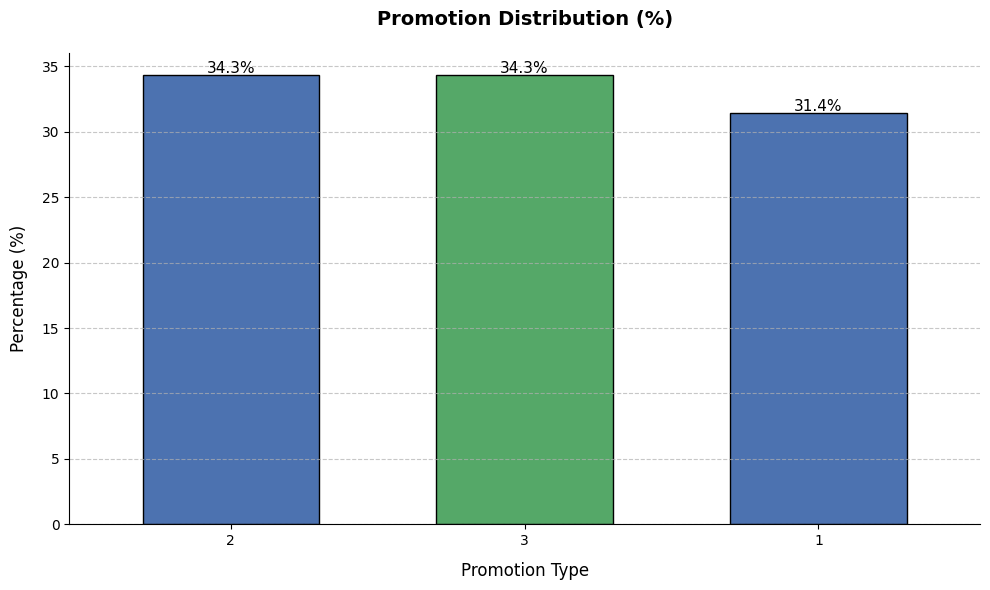

In [10]:
ax = (df['Promotion'].value_counts(normalize=True)*100).plot(
    kind='bar',
    figsize=(10, 6),                # Larger figure size
    color=['#4C72B0', '#55A868'],    # Custom colors (blue and green)
    edgecolor='black',               # Black edges for bars
    linewidth=1,                     # Edge line width
    rot=0,                           # No rotation for x-axis labels
    width=0.6                        # Adjust bar width
)

# Add title and labels with improved formatting
plt.title('Promotion Distribution (%)', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Promotion Type', fontsize=12, labelpad=10)
plt.ylabel('Percentage (%)', fontsize=12, labelpad=10)

# Add percentage labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 5), 
                textcoords='offset points',
                fontsize=11)

# Customize grid and spines
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout and padding
plt.tight_layout()

# Show the plot
plt.show()

from the above plot , we see the dataset is quite balanced between the 3 promotion plans

### Metric

Now we continue to check the metric (Sales in thousands) , and how it is distributed

In [11]:
def num_dist_plot(df , variable) : 
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,10))
    # to avoid nuisance of warnings 
    warnings.filterwarnings("ignore", category=FutureWarning)
    sns.histplot(data=df , x = variable , ax = ax1,  kde=True)
    # running shapiro test of normality 
    stat, p = stats.shapiro(df[variable])
    
    if p < 0.05 : 
        ax1.set_title(f"histogram of {variable}  showing that it does not follow normal distribution")
    else :
        ax1.set_title(f"histogram of {variable} showing that it we can not reject that it follows normal distribution")
    sns.boxplot(data=df , y = variable, ax = ax2)
    ax2.set_title(f"Boxplot of {variable}")
    plt.show()
        



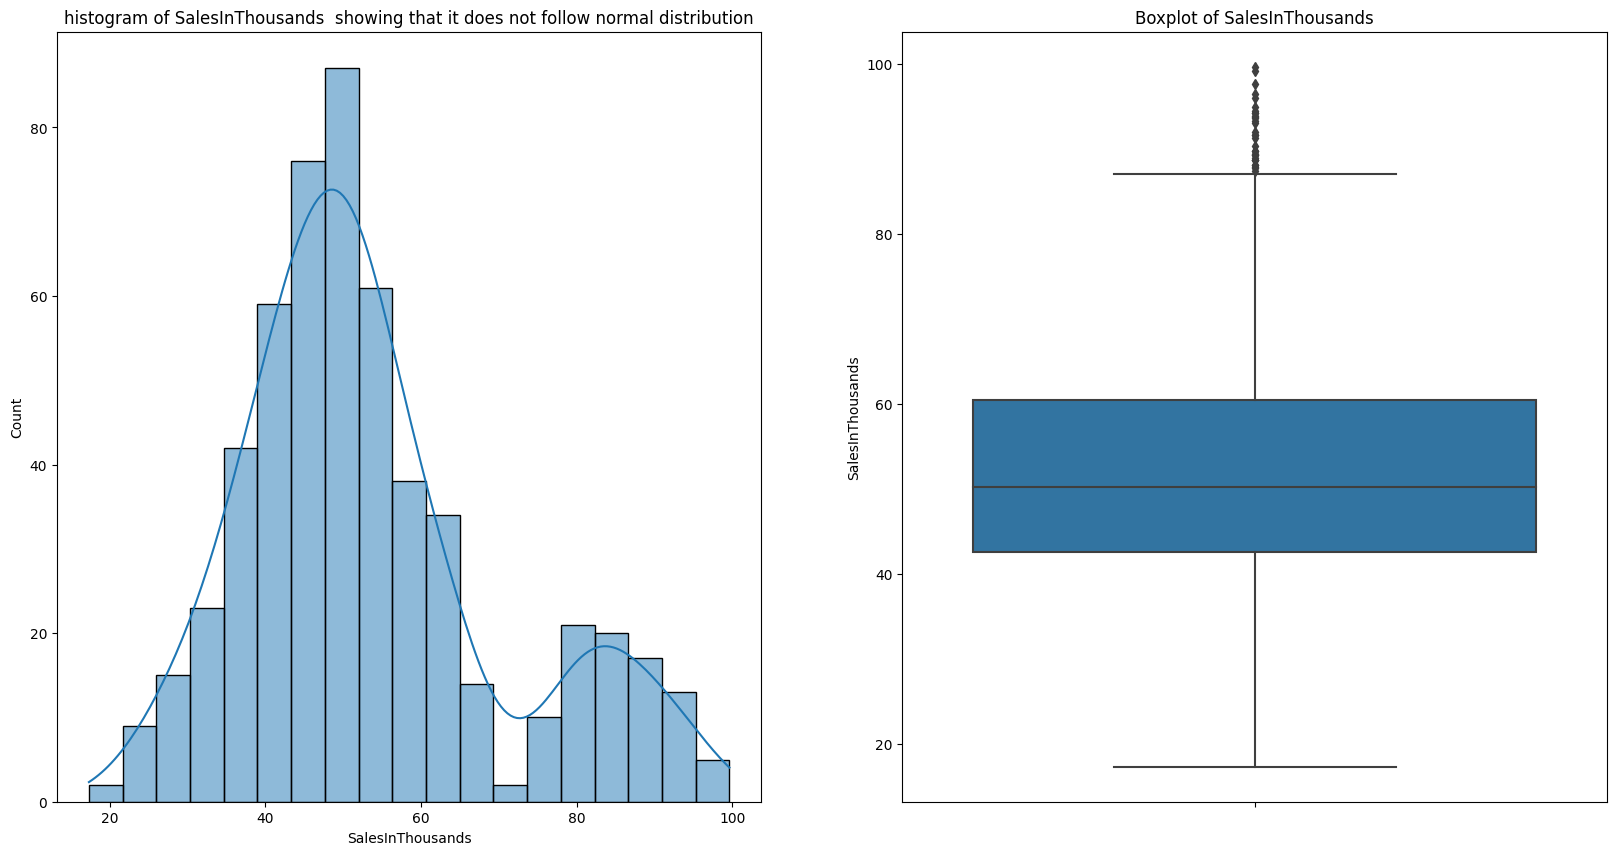

In [12]:
num_dist_plot(df , "SalesInThousands")

<div style="border-radius: 22px; font-size:130%; text-align:left">


From the above chart we can see that the SalesInThousands has a median around 50 thousand $ , and it not distributed normally


<div style="border-radius: 22px; font-size:150%; text-align:left">

* Bivariate analysis : Explore relationships between two variables.





<div style="border-radius: 22px; font-size:130%; text-align:left">
Check first whether Age of store has a relationship  with sales in thousands

In [13]:
stats.pearsonr(df["AgeOfStore"] , df["SalesInThousands"])

PearsonRResult(statistic=-0.02853288110249568, pvalue=0.5050607939715025)

<Axes: xlabel='AgeOfStore', ylabel='SalesInThousands'>

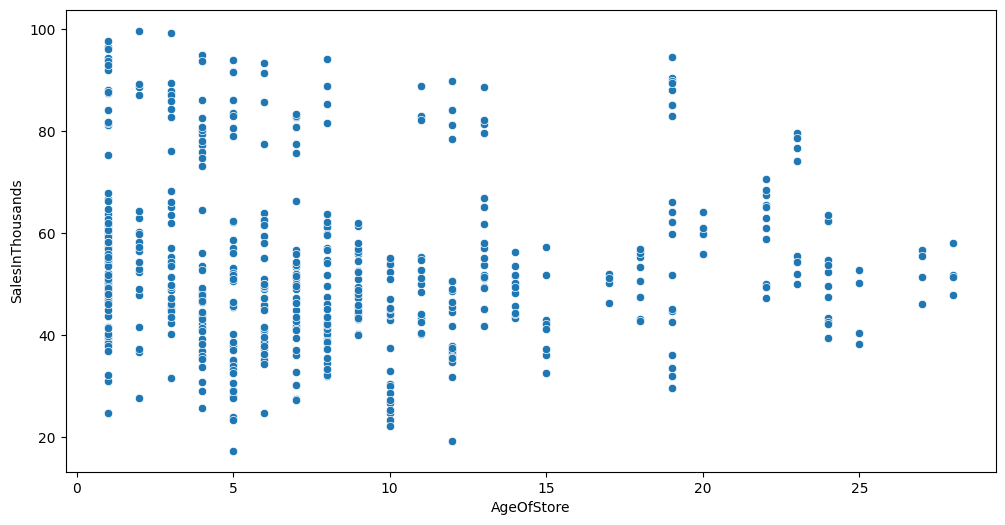

In [14]:
plt.figure(figsize=(12, 6))

sns.scatterplot(data = df , x ="AgeOfStore" , y =  "SalesInThousands")

Here it is not clear that there is a linear significant relationship between age of store and sales in thousands. However it is a slight negative relationship

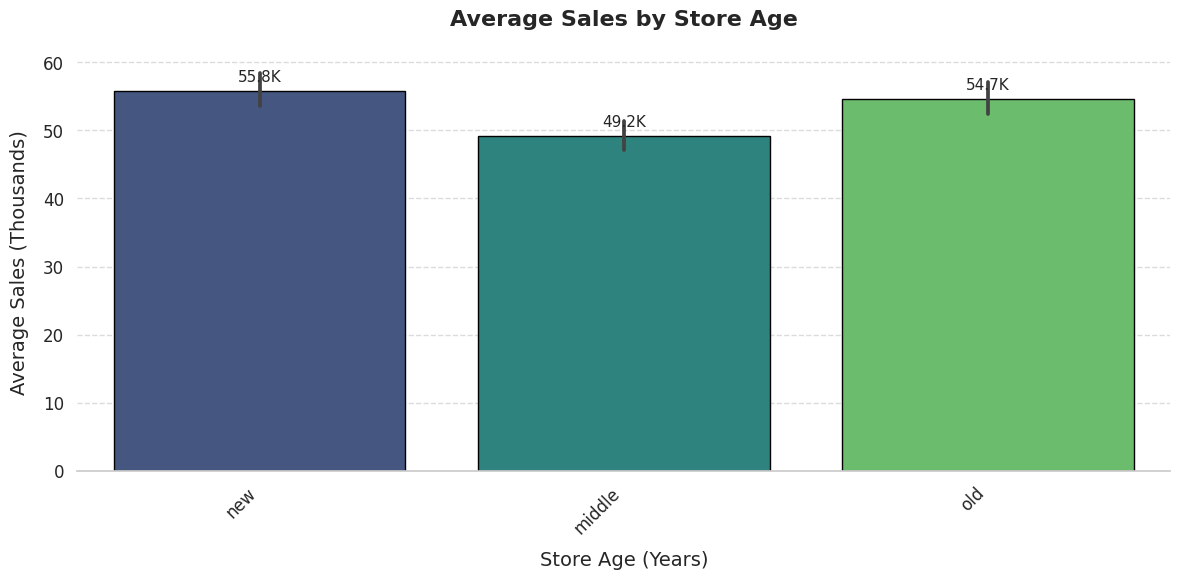

In [15]:
# Set style and context
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Create the plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df,
    y="SalesInThousands",
    x="store_age",
    estimator='mean',
    palette="viridis",  # Or try "rocket", "mako", or "flare"
    ci=95,  # 95% confidence intervals
    edgecolor="black",
    linewidth=1
)

# Customize title and labels
plt.title('Average Sales by Store Age', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Store Age (Years)', fontsize=14, labelpad=10)
plt.ylabel('Average Sales (Thousands)', fontsize=14, labelpad=10)

# Rotate x-axis labels if needed
plt.xticks(rotation=45, ha='right')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}K',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=11
    )

# Customize grid and spines
ax.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine(left=True)

# Adjust layout
plt.tight_layout()
plt.show()

However from the data we have we see that newer stores have relatevily larger average sales.


<div style="border-radius: 22px; font-size:130%; text-align:left">
then comes the more important relationship to check , which is matter of our search , relationship between different promotion plans and does average sales in thousands vary among them.

to have a basic impact , we check the average sales  

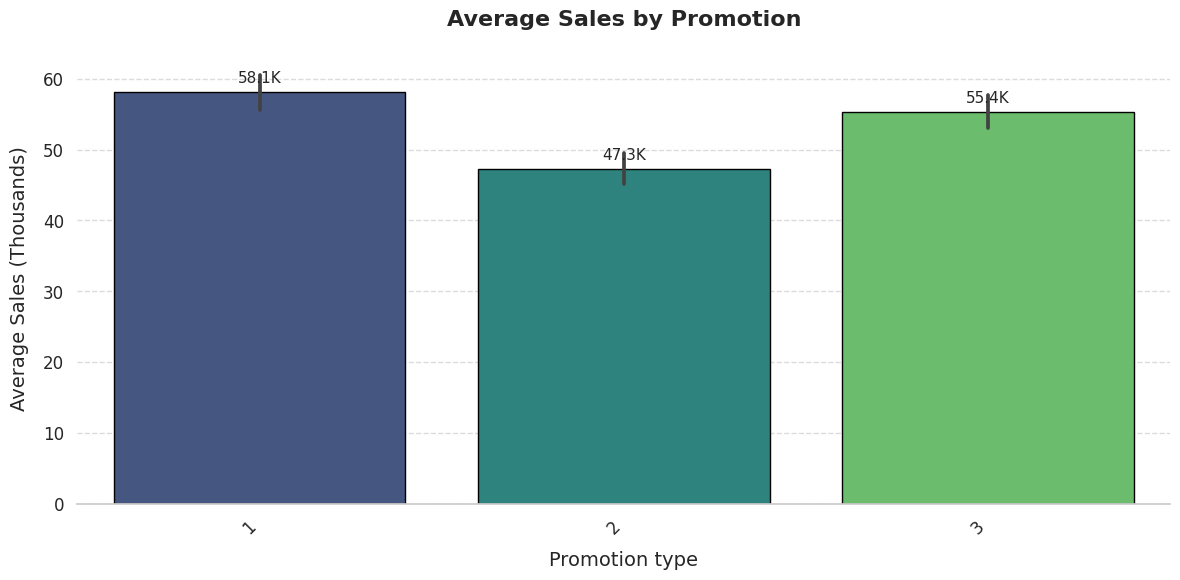

In [16]:
# Set style and context
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.1)

# Create the plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df,
    y="SalesInThousands",
    x="Promotion",
    estimator='mean',
    palette="viridis",  # Or try "rocket", "mako", or "flare"
    ci=95,  # 95% confidence intervals
    edgecolor="black",
    linewidth=1
)

# Customize title and labels
plt.title('Average Sales by Promotion', fontsize=16, pad=20, fontweight='bold')
plt.xlabel('Promotion type', fontsize=14, labelpad=10)
plt.ylabel('Average Sales (Thousands)', fontsize=14, labelpad=10)

# Rotate x-axis labels if needed
plt.xticks(rotation=45, ha='right')

# Add value labels on top of bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}K',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=11
    )

# Customize grid and spines
ax.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine(left=True)

# Adjust layout
plt.tight_layout()
plt.show()

we see that average sales yielded from promotion plan look relatevely lower than those of promotions 1 and 3 

<div style="border-radius: 22px; font-size:130%; text-align:center">
 but is this significant , on other words is this visual impact generalizable ? , thats where the process of testing helps 

but before testing , we choose the most proper test for our data , make sure that it is valid

### Validating tests' assumptions


<div style="border-radius: 20px; border:#9B8BA8 solid; padding: 15px; background-color: #A6E6FA; font-size:130%; text-align:center">

# C -  Validating tests'  assumptions


the first test that comes to mind in this case , more than two groups is ANOVA , but this assumes normality and from above section we see that SalesInThousands does not follow normal distribution.

so we see our groups are balanced regarding size, as well regarding applying Kruskal-Wallis non parametric test it assumes that  distributions of the groups have the same shape with  similar variability and skewness

We validate that both graphically using histogram to plot the 3 groups

<Axes: xlabel='SalesInThousands', ylabel='Count'>

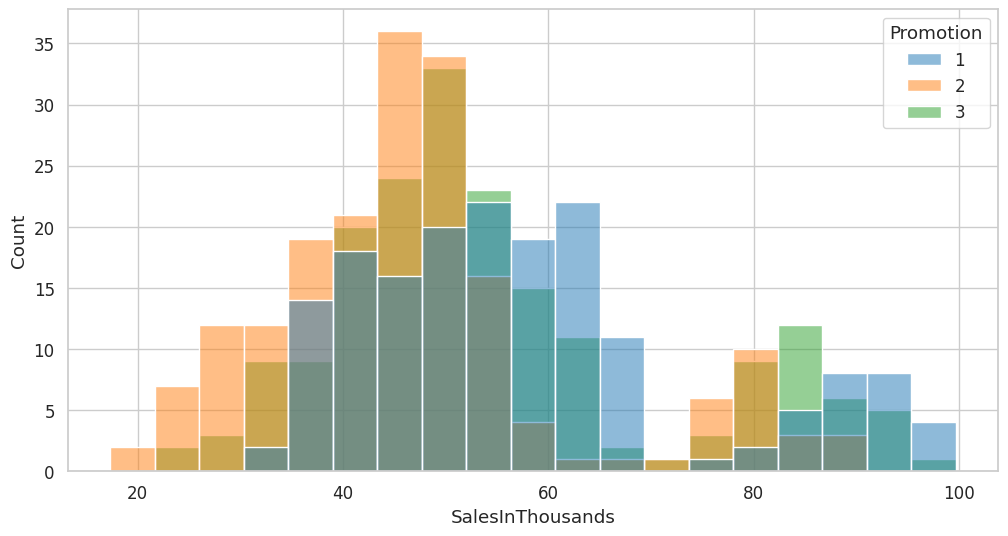

In [17]:
plt.figure(figsize=(12, 6))

sns.histplot(hue = 'Promotion' , x ="SalesInThousands"  , data = df)

we see from the graph that the 3 groups have a similar looking distribution , thrice of them skewed to the left 

  to make sure they share similar variability we use levene test which evaluates the null hypothesis that the variances of the groups are equal. If the test result is significant (typically 
p
<
0.05
), it suggests that the variances are not equal across groups, and the null hypothesis is rejected as : 

<div style="color:red;  font-size:150%">

    
Null Hypothesis (
H0): The variances of all groups are equal.
</div> 



<div style="color:red;  font-size:150%">

Alternative Hypothesis (
H1): At least one group has a variance that is different from the others.
</div> 


In [18]:
promotion1 = df.loc[df['Promotion']==1 , ['SalesInThousands']]
promotion2 = df.loc[df['Promotion']==2 , ['SalesInThousands']]
promotion3 = df.loc[df['Promotion']==3 , ['SalesInThousands']]

In [19]:
stats.levene(promotion1 , promotion2 , promotion3)

LeveneResult(statistic=array([1.26967875]), pvalue=array([0.28175146]))

from the above result we do not reject H0 that the variances of the 3 groups are equal.

As we checked homogenity of distribution between the 3 groups , now it is safe to use Kruskal Wallis non parametric test.

### run the test


<div style="border-radius: 20px; border:#9B8BA8 solid; padding: 15px; background-color: #A6E6FA; font-size:130%; text-align:center">

# D -  Running the test



<div style="border-radius: 22px; font-size:150%; text-align:center">


**So what is Kruskal Wallis test?**


it is a non parametric test to  compare the distributions of three or more independent groups , like in our case no customer tried the three promotions so we can say that sample is dependent.


in this case we have






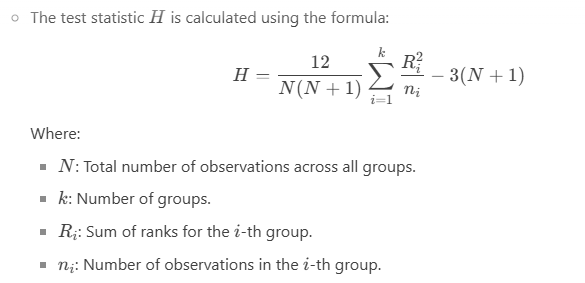

<div style="color:red;  font-size:150%">
H0 : that the 3 groups have the same distribution (this includes they have the same average of sales in thousands ) 

</div>




<div style="color:red;  font-size:150%">

H1 : At least one of the groups has a different one
</div>


it works based on ranking the combined group of the 3 groups from smallest to largest.


then calculate the test statistic 

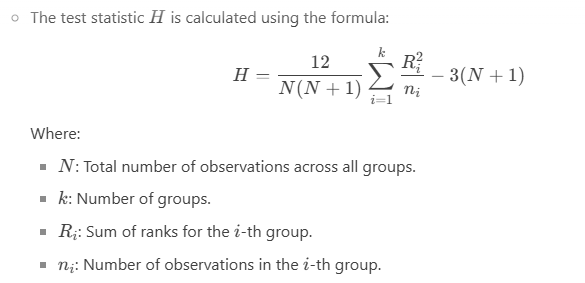

this statistic follows chi - squared distribution, we get the P value and if it is less than a critical value , we assume it here by 0.05 , we reject the H0.

In [20]:
test , p = stats.kruskal(promotion1 , promotion2 , promotion3)

In [21]:
p < 0.05

array([ True])

Thus we reject H0 , at least we have one of the groups has a different mean sales in thousands.

but the test statistic result gives us just a hint that there is difference between the 3 groups , what is the direction of this difference ( which promotion plan sell more) , which promotion made sales increase , in which subgroup each promotion masters , all of this we need to explore later.

First we check the order of effect of these promotion plans

<Axes: xlabel='Promotion', ylabel='SalesInThousands'>

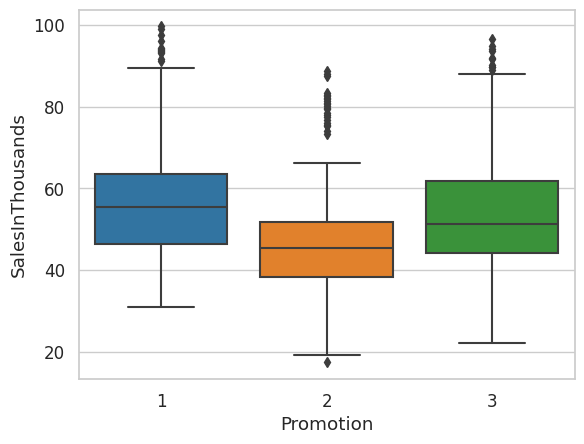

In [22]:
sns.boxplot(data=df , y = "SalesInThousands", x  = "Promotion" )


<span style="font-size:150%">

from the above plot , we see graphically that clearly the promotion 1 has an edge , followed by promotion 3 , with promotion 2 has the least average of sales in thousands.

<span>

now let's check whether these differences are significant , safe to generalize , we run Kolmogorov-Smirnov Test , which is a non parametric test that compares the cumulative distribution functions of two samples or compares one sample to a reference probability.

we run this test mutuallly between each two promotion category sales data

let's start by testing sales resulted from promotion 1 vs sales resulting from promotion 3  :



<div style="color:red;  font-size:150%">

    
H0 : the 2 promotions sales follow the same distribution (this includes they have the same average of sales in thousands )

</div>





<div style="color:red;  font-size:150%">

H1 : they don't have the same distribution

</div>

In [23]:
stat13 , p13 = stats.ks_2samp(promotion1, promotion3)
print((p13 < 0.05)[0])


True


thus we reject H0 and we state that , there is a significant difference between sales resulted from promotion 1 and sales resulted from promotion 3 , from the graph above we see that direction of difference is in the side of promotion 1

In [24]:
stat12 , p12 = stats.ks_2samp(promotion1, promotion2)
print((p12 < 0.05)[0])


True


thus we reject H0 and we state that , there is a significant difference between sales resulted from promotion 1 and sales resulted from promotion 2 , from the graph above we see that direction of difference is in the side of promotion 1

In [25]:
stat23 , p23 = stats.ks_2samp(promotion1, promotion2)
print((p23 < 0.05)[0])


True




thus we reject H0 and we state that , there is a significant difference between sales resulted from promotion 2 and sales resulted from promotion 3 , from the graph above we see that direction of difference is in the side of promotion 3

<div style="border-radius: 22px; font-size:150%; text-align:center">

We can conclude that there is a significant difference between sales across different pormotion plans , the best one from this prospective is promotion 1 followed by promotion 3 and the least effective plan is promotion 2.

### Studying confounding variables effect 


<div style="border-radius: 20px; border:#9B8BA8 solid; padding: 15px; background-color: #A6E6FA; font-size:130%; text-align:center">

# E -  Studying confounding variables effect 


<div style="border-radius: 22px; font-size:150%; text-align:center">

**What are confounding variables ?**


A confounding variable is an external factor that:

Correlates with the independent variable (e.g., the treatment in A/B testing like promotions in our case).

Directly affects the dependent variable (e.g., the outcome metric like sales in our case).

If not controlled, confounders can lead to biased results, making it seem like the treatment caused the outcome when it was actually the confounder.

In our case , what we should take into consideration , that if one of promotions was applied in a week , market size , or specific stores that already has significant different sales pattern than other weeks , market sizes and stores

In [26]:
def confounding_effects(df , break_variable , metric , confounding_vaiable):
    fig, (ax1, ax2 , ax3) = plt.subplots(1, 3, figsize=(15,5))

    # studying the relationship between the confounding variable and break variable
    sns.countplot(data=df , hue = break_variable , x  = confounding_vaiable , ax = ax1)
  
    # studying the relationship between the confounding variable and metric
    sns.barplot(x = confounding_vaiable , y =metric  , data = df ,  estimator = 'mean', ax = ax2)
    # studying whether the behaviour if metric across breaks vary per confounding variable
    sns.barplot(data=df , y = metric, hue  = break_variable, x = confounding_vaiable , estimator = 'mean' , ax = ax3)
    

### **Studying the confounding effect of market size :**

<Axes: xlabel='MarketSize', ylabel='count'>

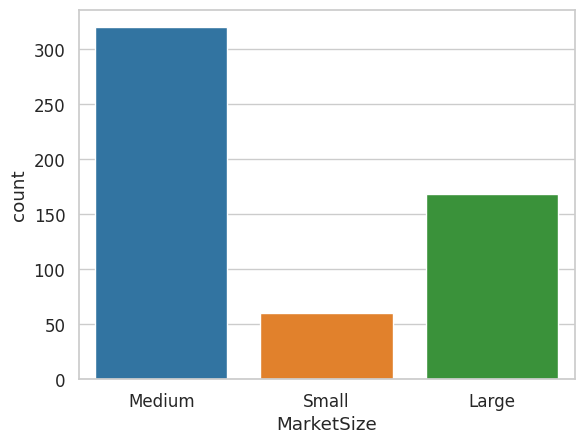

In [27]:
sns.countplot(data=df , x = "MarketSize" )
  

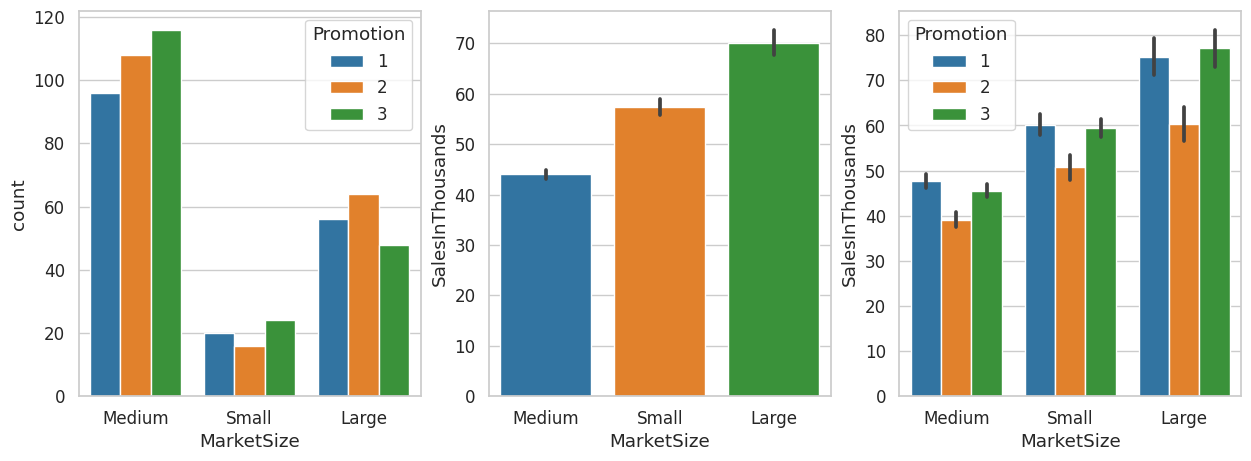

In [28]:
confounding_effects(df, "Promotion","SalesInThousands","MarketSize")

we see from the above that non of market size categories is over represented in any promotion sample , as well , the behaviour of promotion effect across different market sizes do not differ , so it is unlikely that market size has a confounding effect

### **Studying the confounding effect of week :**

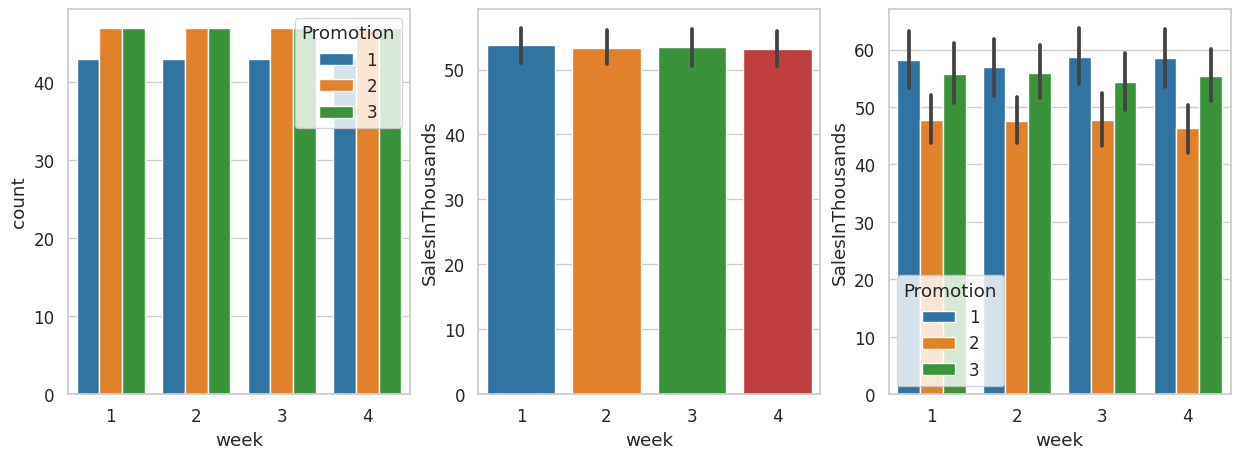

In [29]:
confounding_effects(df, "Promotion","SalesInThousands","week")

we see from the above that non of week categories is over represented in any promotion sample , as well , the behaviour of promotion effect across different market sizes do not differ , so it is unlikely that week has a confounding effect

### **Studying the confounding store age :**

<Axes: xlabel='store_age', ylabel='count'>

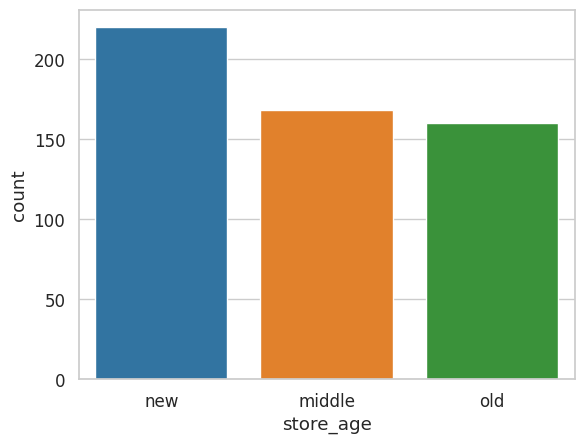

In [30]:
sns.countplot(data=df , x = "store_age" )


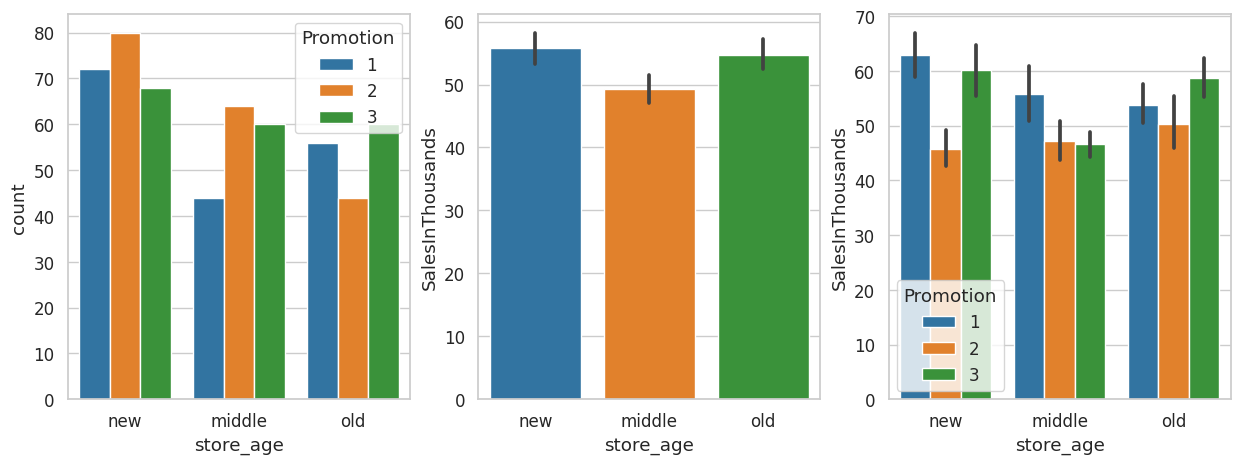

In [31]:
confounding_effects(df, "Promotion","SalesInThousands","store_age")

**So how to investigate the potential confounding effect for store age ?**

first we test if the metric (sales) varies significantly across store age categories  

from the above we see that  there is no balance in distributiong promotions across store age categories. In new and middle aged stores , promotion 2 is the most represented one , however in old stores it is the least represented one.

This may be because it was relatively recently launched.







<div style="color:Green;  font-size:150%">
As well we see that behaviour of sales per promotion plan varies across store age categories.
    
while the behaviour in new stores is similar to what we studied above for the whole data promotion 1 > promotion 3 > promotion 2 , 



it is promotion 1 > promotion 2 > promotion 3 in middle aged stores 



and promotion 3 > promotion 1 > promotion 2 in old stores.
</div>

In [32]:
promotion_old = df.loc[ ( df['store_age'] =='old'), ['SalesInThousands']]
promotion_middle = df.loc[(df['store_age'] =='middle') , ['SalesInThousands']]
promotion_new = df.loc[ (df['store_age'] =='new')  , ['SalesInThousands']]

test , p = stats.kruskal(promotion_old , promotion_middle , promotion_new)

In [33]:
p < 0.05

array([ True])

Here we see that difference in the above chart is significant  

To make sure that difference in the test between the 3 promotion plans is real and not due to distributing promotion plans among stores from different age category , 



In [34]:
promotion1_old = df.loc[(df['Promotion']==1 ) & ( df['store_age'] =='old'), ['SalesInThousands']]
promotion2_old = df.loc[(df['Promotion']==2) & (df['store_age'] =='old') , ['SalesInThousands']]
promotion3_old = df.loc[(df['Promotion']==3) & (df['store_age'] =='old')  , ['SalesInThousands']]

test , p = stats.kruskal(promotion1_old , promotion2_old , promotion3_old)

In [35]:
p < 0.05

array([ True])

In [36]:
promotion1_middle = df.loc[(df['Promotion']==1) & ( df['store_age'] =='middle') , ['SalesInThousands']]
promotion2_middle = df.loc[(df['Promotion']==2) & ( df['store_age'] =='middle'), ['SalesInThousands']]
promotion3_middle = df.loc[(df['Promotion']==3) & ( df['store_age'] =='middle'), ['SalesInThousands']]

test , p = stats.kruskal(promotion1_middle , promotion2_middle , promotion3_middle)

In [37]:
p < 0.05

array([ True])

In [38]:
promotion1_new = df.loc[(df['Promotion']==1) & ( df['store_age'] =='new') , ['SalesInThousands']]
promotion2_new = df.loc[(df['Promotion']==2) & ( df['store_age'] =='new'), ['SalesInThousands']]
promotion3_new = df.loc[(df['Promotion']==3) & ( df['store_age'] =='new'), ['SalesInThousands']]

test , p = stats.kruskal(promotion2_new , promotion1_new , promotion3_new)

In [39]:
p < 0.05

array([ True])

From above we see that there is a significant different between sales resulting from different promotion plans  across storage age categories .


We can say that the confounding effect of store age does not effect in existing of difference between promotion plans , it reather effects the direction.


<div style="border-radius: 20px; border:#9B8BA8 solid; padding: 15px; background-color: #A6E6FA; font-size:130%; text-align:center">

# F -  Conclusion

Finally , we can sum up results that there is a significant difference in sales resulting from different promotion plans , but we should take into consideration effect of store age.


for newer stores we can order sales per promotion as folllows promotion 1 > promotion 3 > promotion 2

for old stores promotion 3 > promotion 1 > promotion 2 


for middle age stores promotion 1 > promotion 2 > promotion 3 